# Klasifikasi Popularitas Lagu Spotify
## UAP Pembelajaran Mesin

**Dataset**: Spotify Global Music Dataset (2009–2025)

**Tujuan**: Mengklasifikasikan popularitas lagu menjadi 3 kelas:
- Tidak Populer (0-33)
- Populer (34-66)
- Sangat Populer (67-100)

**Model yang digunakan**:
1. MLP (Multilayer Perceptron) - Baseline
2. TabNet - Transfer Learning dengan Attention Mechanism
3. FT-Transformer - Transformer untuk Data Tabular

## 1. Import Libraries

In [1]:
# Data manipulation
import pandas as pd
import numpy as np
import json
import joblib
import warnings
warnings.filterwarnings('ignore')

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
plt.style.use('seaborn-v0_8-darkgrid')

# Sklearn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# TensorFlow/Keras for MLP
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, callbacks

# PyTorch for TabNet
import torch
from pytorch_tabnet.tab_model import TabNetClassifier

print(f"TensorFlow version: {tf.__version__}")
print(f"PyTorch version: {torch.__version__}")
print(f"GPU Available: {tf.config.list_physical_devices('GPU')}")

TensorFlow version: 2.20.0
PyTorch version: 2.9.1+cpu
GPU Available: []


## 2. Load Data & Exploratory Data Analysis (EDA)

In [2]:
# Load dataset
df = pd.read_csv('Dataset/spotify_data clean.csv')

print(f"Dataset shape: {df.shape}")
print(f"\nColumns: {df.columns.tolist()}")
print(f"\nFirst 5 rows:")
df.head()

Dataset shape: (8582, 15)

Columns: ['track_id', 'track_name', 'track_number', 'track_popularity', 'explicit', 'artist_name', 'artist_popularity', 'artist_followers', 'artist_genres', 'album_id', 'album_name', 'album_release_date', 'album_total_tracks', 'album_type', 'track_duration_min']

First 5 rows:


,track_id,track_name,track_number,track_popularity,explicit,artist_name,artist_popularity,artist_followers,artist_genres,album_id,album_name,album_release_date,album_total_tracks,album_type,track_duration_min
0,3EJS5LyekDim1Tf5rBFmZl,Trippy Mane (ft. Project Pat),4,0,True,Diplo,77,2812821,moombahton,5QRFnGnBeMGePBKF2xTz5z,"d00mscrvll, Vol. 1",2025-10-31,9,album,1.55
1,1oQW6G2ZiwMuHqlPpP27DB,OMG!,1,0,True,Yelawolf,64,2363438,"country hip hop, southern hip hop",4SUmmwnv0xTjRcLdjczGg2,OMG!,2025-10-31,1,single,3.07
2,7mdkjzoIYlf1rx9EtBpGmU,Hard 2 Find,1,4,True,Riff Raff,48,193302,NaN,3E3zEAL8gUYWaLYB9L7gbp,Hard 2 Find,2025-10-31,1,single,2.55
3,67rW0Zl7oB3qEpD5YWWE5w,Still Get Like That (ft. Project Pat & Starrah),8,30,True,Diplo,77,2813710,moombahton,5QRFnGnBeMGePBKF2xTz5z,"d00mscrvll, Vol. 1",2025-10-31,9,album,1.69
4,15xptTfRBrjsppW0INUZjf,ride me like a harley,2,0,True,Rumelis,48,8682,dark r&b,06FDIpSHYmZAZoyuYtc7kd,come closer / ride me like a harley,2025-10-30,2,single,2.39


In [3]:
# Dataset info
print("Dataset Information:")
df.info()

print("\n" + "="*50)
print("Missing Values:")
print(df.isnull().sum())

print("\n" + "="*50)
print("Statistical Summary:")
df.describe()

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8582 entries, 0 to 8581
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   track_id            8582 non-null   object 
 1   track_name          8582 non-null   object 
 2   track_number        8582 non-null   int64  
 3   track_popularity    8582 non-null   int64  
 4   explicit            8582 non-null   bool   
 5   artist_name         8579 non-null   object 
 6   artist_popularity   8582 non-null   int64  
 7   artist_followers    8582 non-null   int64  
 8   artist_genres       5221 non-null   object 
 9   album_id            8582 non-null   object 
 10  album_name          8582 non-null   object 
 11  album_release_date  8582 non-null   object 
 12  album_total_tracks  8582 non-null   int64  
 13  album_type          8582 non-null   object 
 14  track_duration_min  8582 non-null   float64
dtypes: bool(1), float64(1), int64(5), 

,track_number,track_popularity,artist_popularity,artist_followers,album_total_tracks,track_duration_min
count,8582.000000,8582.000000,8582.000000,8.582000e+03,8582.000000,8582.000000
mean,5.772547,52.356211,69.730016,2.403472e+07,13.789443,3.492805
std,6.052792,23.816076,19.645979,3.803180e+07,11.887131,1.057970
min,1.000000,0.000000,0.000000,0.000000e+00,1.000000,0.070000
25%,1.000000,39.000000,60.000000,4.623200e+05,6.000000,2.880000
50%,4.000000,58.000000,74.000000,6.105547e+06,13.000000,3.445000
75%,9.000000,71.000000,84.000000,2.725255e+07,17.000000,3.990000
max,102.000000,99.000000,100.000000,1.455421e+08,181.000000,13.510000


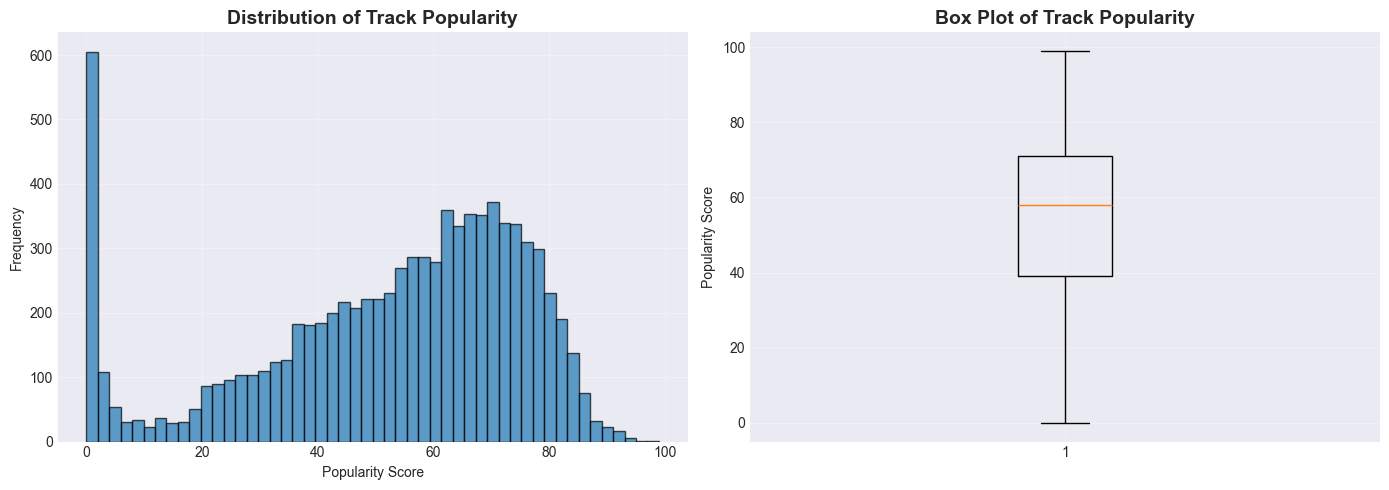

Popularity Statistics:
count    8582.000000
mean       52.356211
std        23.816076
min         0.000000
25%        39.000000
50%        58.000000
75%        71.000000
max        99.000000
Name: track_popularity, dtype: float64


In [4]:
# Analyze target variable (track_popularity)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribution
axes[0].hist(df['track_popularity'], bins=50, edgecolor='black', alpha=0.7)
axes[0].set_title('Distribution of Track Popularity', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Popularity Score')
axes[0].set_ylabel('Frequency')
axes[0].grid(True, alpha=0.3)

# Box plot
axes[1].boxplot(df['track_popularity'], vert=True)
axes[1].set_title('Box Plot of Track Popularity', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Popularity Score')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('train_image_result/01_popularity_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"Popularity Statistics:")
print(df['track_popularity'].describe())

### Create Popularity Classes

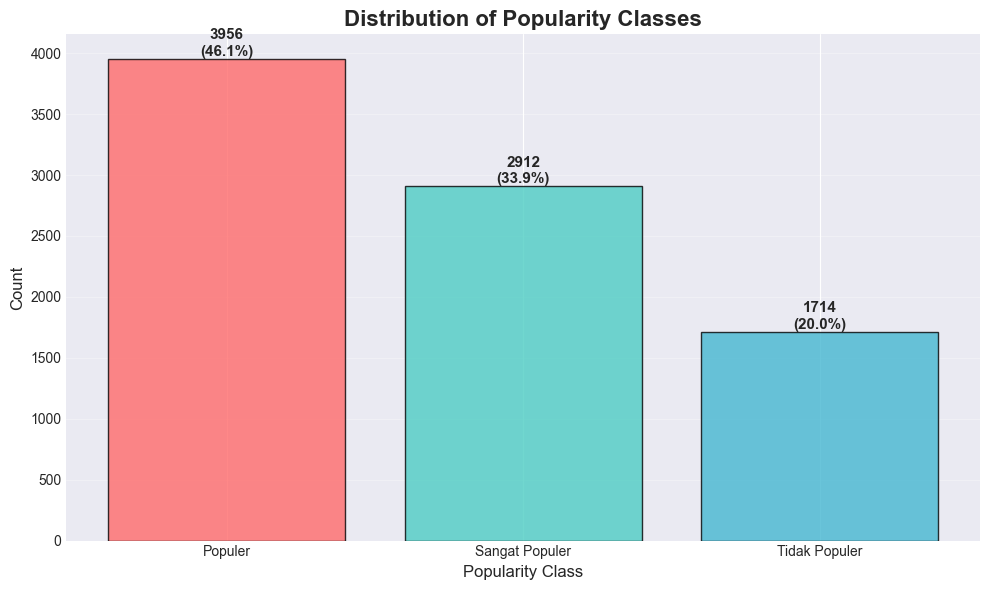


Class Distribution:
popularity_class
Populer           3956
Sangat Populer    2912
Tidak Populer     1714
Name: count, dtype: int64

Class Percentages:
popularity_class
Populer           46.096481
Sangat Populer    33.931485
Tidak Populer     19.972034
Name: count, dtype: float64


In [5]:
# Create 3 popularity classes
def categorize_popularity(score):
    if score <= 33:
        return 'Tidak Populer'
    elif score <= 66:
        return 'Populer'
    else:
        return 'Sangat Populer'

df['popularity_class'] = df['track_popularity'].apply(categorize_popularity)

# Visualize class distribution
plt.figure(figsize=(10, 6))
class_counts = df['popularity_class'].value_counts()
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1']
bars = plt.bar(class_counts.index, class_counts.values, color=colors, edgecolor='black', alpha=0.8)

plt.title('Distribution of Popularity Classes', fontsize=16, fontweight='bold')
plt.xlabel('Popularity Class', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.grid(axis='y', alpha=0.3)

# Add value labels on bars
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
             f'{int(height)}\n({height/len(df)*100:.1f}%)',
             ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig('train_image_result/02_class_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nClass Distribution:")
print(class_counts)
print(f"\nClass Percentages:")
print(class_counts / len(df) * 100)

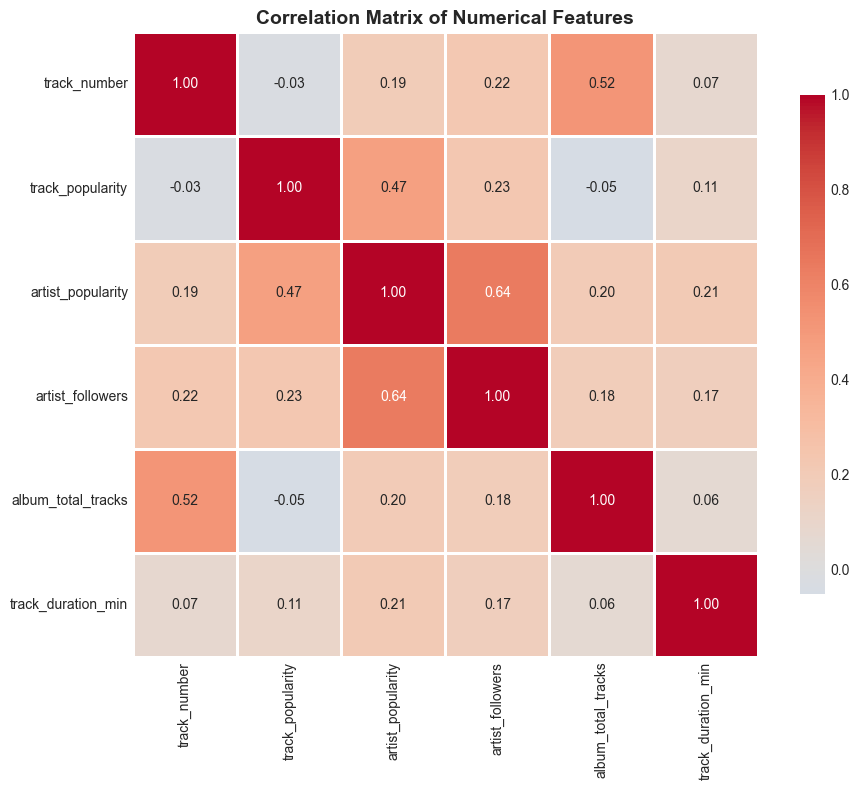

In [6]:
# Correlation analysis for numerical features
numerical_cols = ['track_number', 'track_popularity', 'artist_popularity', 
                  'artist_followers', 'album_total_tracks', 'track_duration_min']

plt.figure(figsize=(10, 8))
correlation_matrix = df[numerical_cols].corr()
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', 
            center=0, square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('Correlation Matrix of Numerical Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('train_image_result/03_correlation_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

## 3. Data Preprocessing

In [7]:
# Select features for modeling
# Drop ID columns and text columns that need special processing
features_to_use = ['track_number', 'track_popularity', 'explicit', 
                   'artist_popularity', 'artist_followers', 
                   'album_total_tracks', 'album_type', 'track_duration_min']

# Create feature matrix and target
X = df[features_to_use].copy()
y = df['popularity_class'].copy()

print(f"Feature matrix shape: {X.shape}")
print(f"Target shape: {y.shape}")
print(f"\nFeatures used: {features_to_use}")

Feature matrix shape: (8582, 8)
Target shape: (8582,)

Features used: ['track_number', 'track_popularity', 'explicit', 'artist_popularity', 'artist_followers', 'album_total_tracks', 'album_type', 'track_duration_min']


In [8]:
# Handle missing values
print("Missing values before handling:")
print(X.isnull().sum())

# Fill missing values
X['track_duration_min'].fillna(X['track_duration_min'].median(), inplace=True)
X['album_type'].fillna('unknown', inplace=True)

print("\nMissing values after handling:")
print(X.isnull().sum())

Missing values before handling:
track_number          0
track_popularity      0
explicit              0
artist_popularity     0
artist_followers      0
album_total_tracks    0
album_type            0
track_duration_min    0
dtype: int64

Missing values after handling:
track_number          0
track_popularity      0
explicit              0
artist_popularity     0
artist_followers      0
album_total_tracks    0
album_type            0
track_duration_min    0
dtype: int64


In [9]:
# Encode categorical features
# Convert boolean to int
X['explicit'] = X['explicit'].astype(int)

# Label encode album_type
le_album = LabelEncoder()
X['album_type_encoded'] = le_album.fit_transform(X['album_type'])
X = X.drop('album_type', axis=1)

# Encode target variable
le_target = LabelEncoder()
y_encoded = le_target.fit_transform(y)

print("Encoded features:")
print(X.head())
print(f"\nTarget classes: {le_target.classes_}")
print(f"Encoded target: {np.unique(y_encoded)}")

Encoded features:
   track_number  track_popularity  explicit  artist_popularity  \
0             4                 0         1                 77   
1             1                 0         1                 64   
2             1                 4         1                 48   
3             8                30         1                 77   
4             2                 0         1                 48   

   artist_followers  album_total_tracks  track_duration_min  \
0           2812821                   9                1.55   
1           2363438                   1                3.07   
2            193302                   1                2.55   
3           2813710                   9                1.69   
4              8682                   2                2.39   

   album_type_encoded  
0                   0  
1                   2  
2                   2  
3                   0  
4                   2  

Target classes: ['Populer' 'Sangat Populer' 'Tidak Populer']


In [10]:
# Train/Validation/Test split (70/15/15)
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y_encoded, test_size=0.15, random_state=42, stratify=y_encoded
)

X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.176, random_state=42, stratify=y_temp  # 0.176 * 0.85 ≈ 0.15
)

print(f"Training set: {X_train.shape}")
print(f"Validation set: {X_val.shape}")
print(f"Test set: {X_test.shape}")

print(f"\nClass distribution in training set:")
unique, counts = np.unique(y_train, return_counts=True)
for cls, cnt in zip(unique, counts):
    print(f"  {le_target.classes_[cls]}: {cnt} ({cnt/len(y_train)*100:.1f}%)")

Training set: (6010, 8)
Validation set: (1284, 8)
Test set: (1288, 8)

Class distribution in training set:
  Populer: 2770 (46.1%)
  Sangat Populer: 2039 (33.9%)
  Tidak Populer: 1201 (20.0%)


In [11]:
# Normalize features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

print("Scaled features shape:")
print(f"Train: {X_train_scaled.shape}")
print(f"Val: {X_val_scaled.shape}")
print(f"Test: {X_test_scaled.shape}")

Scaled features shape:
Train: (6010, 8)
Val: (1284, 8)
Test: (1288, 8)


In [12]:
# Save preprocessing pipeline
preprocessing_pipeline = {
    'scaler': scaler,
    'label_encoder_target': le_target,
    'label_encoder_album': le_album,
    'feature_names': X.columns.tolist()
}

joblib.dump(preprocessing_pipeline, 'models/preprocessing_pipeline.pkl')
print("Preprocessing pipeline saved to models/preprocessing_pipeline.pkl")

Preprocessing pipeline saved to models/preprocessing_pipeline.pkl


## 4. Model 1: MLP (Multilayer Perceptron) - Baseline

Neural network sederhana yang dibangun dari nol tanpa pretrained weights.

In [13]:
# Build MLP model
def create_mlp_model(input_dim, num_classes):
    model = models.Sequential([
        layers.Input(shape=(input_dim,)),
        layers.Dense(128, activation='relu', name='dense_1'),
        layers.Dropout(0.3, name='dropout_1'),
        layers.Dense(64, activation='relu', name='dense_2'),
        layers.Dropout(0.3, name='dropout_2'),
        layers.Dense(32, activation='relu', name='dense_3'),
        layers.Dense(num_classes, activation='softmax', name='output')
    ])
    
    model.compile(
        optimizer='adam',
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    
    return model

mlp_model = create_mlp_model(X_train_scaled.shape[1], len(le_target.classes_))
mlp_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_1 (Dense)                 │ (None, 128)            │         1,152 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 3)              │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,587 (45.26 KB)

 Trainable params: 11,587 (45.26 KB)

 Non-trainable params: 0 (0.00 B)

In [14]:
# Train MLP model
early_stop = callbacks.EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=5,
    min_lr=1e-6,
    verbose=1
)

print("Training MLP model...")
mlp_history = mlp_model.fit(
    X_train_scaled, y_train,
    validation_data=(X_val_scaled, y_val),
    epochs=100,
    batch_size=32,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

Training MLP model...
Epoch 1/100
188/188 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.7664 - loss: 0.5334 - val_accuracy: 0.9400 - val_loss: 0.1829 - learning_rate: 0.0010
Epoch 2/100
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8973 - loss: 0.2397 - val_accuracy: 0.9696 - val_loss: 0.1116 - learning_rate: 0.0010
Epoch 3/100
188/188 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9208 - loss: 0.1847 - val_accuracy: 0.9720 - val_loss: 0.0853 - learning_rate: 0.0010
Epoch 4/100
188/188 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9336 - loss: 0.1530 - val_accuracy: 0.9860 - val_loss: 0.0697 - learning_rate: 0.0010
Epoch 5/100
188/188 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9463 - loss: 0.1262 - val_accuracy: 0.9766 - val_loss: 0.0696 - learning_rate: 0.0010
Epoch 6/100
188/188 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9514 - loss: 0.1132 - val_accuracy: 0.9860 - val_loss: 0.0556 - learning_rate: 0.0010
Epoch 7/100
188/188 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accur

In [15]:
# Save MLP model
mlp_model.save('models/mlp_model.h5')
print("MLP model saved to models/mlp_model.h5")

# Save training history
mlp_history_dict = {
    'loss': [float(x) for x in mlp_history.history['loss']],
    'accuracy': [float(x) for x in mlp_history.history['accuracy']],
    'val_loss': [float(x) for x in mlp_history.history['val_loss']],
    'val_accuracy': [float(x) for x in mlp_history.history['val_accuracy']]
}

with open('models/mlp_history.json', 'w') as f:
    json.dump(mlp_history_dict, f, indent=2)
print("MLP training history saved to models/mlp_history.json")

MLP model saved to models/mlp_model.h5
MLP training history saved to models/mlp_history.json


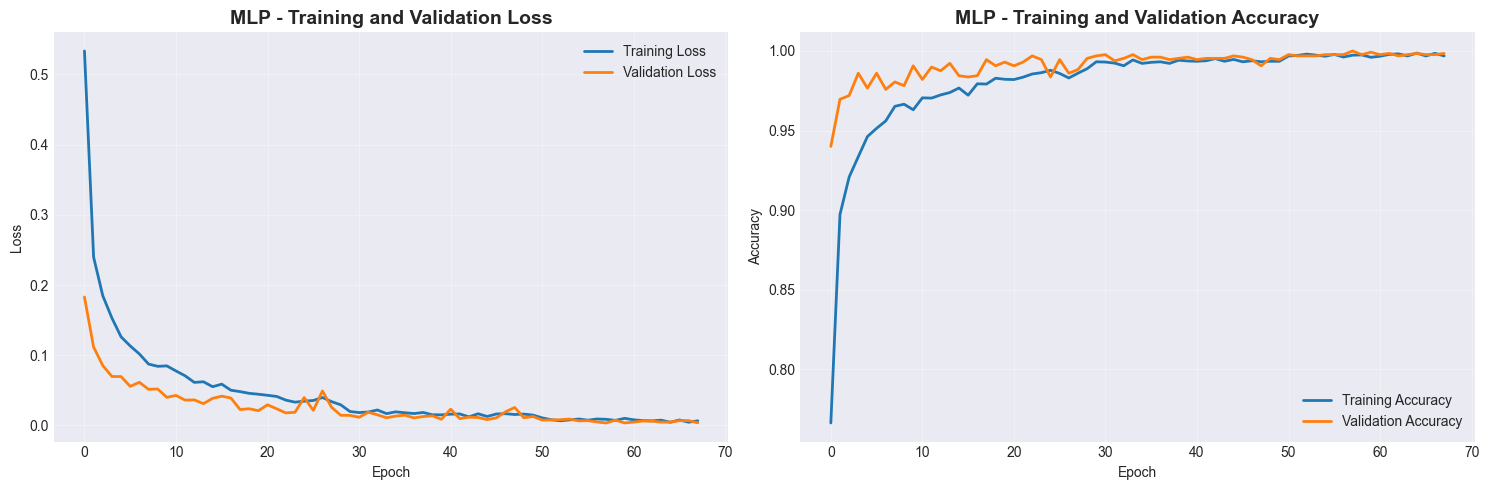

In [16]:
# Plot MLP training curves
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Loss
axes[0].plot(mlp_history.history['loss'], label='Training Loss', linewidth=2)
axes[0].plot(mlp_history.history['val_loss'], label='Validation Loss', linewidth=2)
axes[0].set_title('MLP - Training and Validation Loss', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Accuracy
axes[1].plot(mlp_history.history['accuracy'], label='Training Accuracy', linewidth=2)
axes[1].plot(mlp_history.history['val_accuracy'], label='Validation Accuracy', linewidth=2)
axes[1].set_title('MLP - Training and Validation Accuracy', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('train_image_result/04_mlp_training_curves.png', dpi=300, bbox_inches='tight')
plt.show()

41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
MLP MODEL - TEST SET EVALUATION

Accuracy: 0.9977

Classification Report:
                precision    recall  f1-score   support

       Populer       1.00      1.00      1.00       594
Sangat Populer       1.00      1.00      1.00       437
 Tidak Populer       0.99      1.00      0.99       257

      accuracy                           1.00      1288
     macro avg       1.00      1.00      1.00      1288
  weighted avg       1.00      1.00      1.00      1288



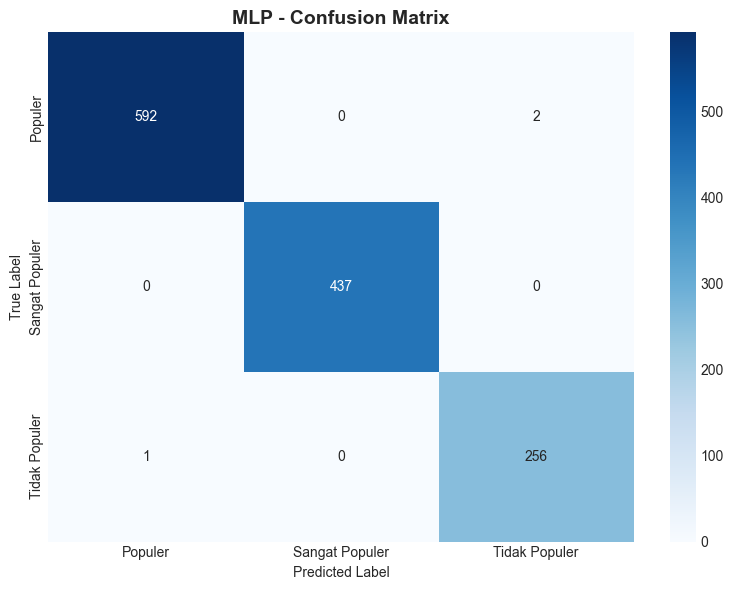

In [17]:
# Evaluate MLP on test set
y_pred_mlp = np.argmax(mlp_model.predict(X_test_scaled), axis=1)
mlp_accuracy = accuracy_score(y_test, y_pred_mlp)

print("="*60)
print("MLP MODEL - TEST SET EVALUATION")
print("="*60)
print(f"\nAccuracy: {mlp_accuracy:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_mlp, target_names=le_target.classes_))

# Confusion matrix
cm_mlp = confusion_matrix(y_test, y_pred_mlp)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_mlp, annot=True, fmt='d', cmap='Blues', 
            xticklabels=le_target.classes_, 
            yticklabels=le_target.classes_)
plt.title('MLP - Confusion Matrix', fontsize=14, fontweight='bold')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.savefig('train_image_result/05_mlp_confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

## 5. Model 2: TabNet - Transfer Learning

### Penjelasan TabNet:

**TabNet** adalah arsitektur deep learning yang dirancang khusus untuk data tabular dengan fitur utama:

1. **Attention Mechanism**: 
   - Menggunakan sequential attention untuk memilih fitur yang paling relevan di setiap langkah keputusan
   - Mirip dengan cara manusia membuat keputusan: fokus pada informasi yang paling penting

2. **Feature Selection**:
   - Secara otomatis memilih subset fitur yang paling informatif
   - Menghasilkan sparse feature selection yang interpretable
   - Mengurangi overfitting dengan fokus pada fitur yang relevan

3. **Self-supervised Learning**:
   - Dapat melakukan pre-training pada data tanpa label
   - Transfer learning dengan fine-tuning pada task spesifik

4. **Interpretability**:
   - Menghasilkan feature importance scores
   - Visualisasi attention masks untuk setiap prediksi

In [18]:
# Create TabNet model
tabnet_model = TabNetClassifier(
    n_d=32,  # Width of the decision prediction layer
    n_a=32,  # Width of the attention embedding
    n_steps=5,  # Number of sequential attention steps
    gamma=1.5,  # Coefficient for feature reusage in attention
    n_independent=2,  # Number of independent GLU layers
    n_shared=2,  # Number of shared GLU layers
    lambda_sparse=1e-4,  # Sparsity regularization
    optimizer_fn=torch.optim.Adam,
    optimizer_params=dict(lr=2e-2),
    scheduler_fn=torch.optim.lr_scheduler.StepLR,
    scheduler_params=dict(step_size=50, gamma=0.9),
    mask_type='sparsemax',  # Attention mask type
    verbose=1,
    seed=42
)

print("TabNet model created with attention mechanism")

TabNet model created with attention mechanism


In [19]:
# Train TabNet model
print("Training TabNet model...")
tabnet_model.fit(
    X_train_scaled, y_train,
    eval_set=[(X_val_scaled, y_val)],
    eval_name=['valid'],
    eval_metric=['accuracy'],
    max_epochs=100,
    patience=15,
    batch_size=256,
    virtual_batch_size=128,
    num_workers=0,
    drop_last=False
)

Training TabNet model...
epoch 0  | loss: 0.63254 | valid_accuracy: 0.8162  |  0:00:01s
epoch 1  | loss: 0.20024 | valid_accuracy: 0.87617 |  0:00:02s
epoch 2  | loss: 0.19135 | valid_accuracy: 0.94626 |  0:00:03s
epoch 3  | loss: 0.14607 | valid_accuracy: 0.93614 |  0:00:04s
epoch 4  | loss: 0.16384 | valid_accuracy: 0.96106 |  0:00:06s
epoch 5  | loss: 0.12612 | valid_accuracy: 0.96573 |  0:00:07s
epoch 6  | loss: 0.18302 | valid_accuracy: 0.92991 |  0:00:08s
epoch 7  | loss: 0.17023 | valid_accuracy: 0.97118 |  0:00:09s
epoch 8  | loss: 0.12349 | valid_accuracy: 0.9743  |  0:00:10s
epoch 9  | loss: 0.12785 | valid_accuracy: 0.96651 |  0:00:11s
epoch 10 | loss: 0.09325 | valid_accuracy: 0.97274 |  0:00:12s
epoch 11 | loss: 0.15259 | valid_accuracy: 0.95872 |  0:00:14s
epoch 12 | loss: 0.12381 | valid_accuracy: 0.98754 |  0:00:15s
epoch 13 | loss: 0.12976 | valid_accuracy: 0.9486  |  0:00:16s
epoch 14 | loss: 0.11302 | valid_accuracy: 0.97975 |  0:00:17s
epoch 15 | loss: 0.102   | val

In [20]:
# Save TabNet model
tabnet_model.save_model('models/tabnet_model')
print("TabNet model saved to models/tabnet_model.zip")

# Save training history
tabnet_history_dict = {
    'loss': [float(x) for x in tabnet_model.history['loss']],
    'val_accuracy': [float(x) for x in tabnet_model.history['valid_accuracy']]
}

with open('models/tabnet_history.json', 'w') as f:
    json.dump(tabnet_history_dict, f, indent=2)
print("TabNet training history saved")

Successfully saved model at models/tabnet_model.zip
TabNet model saved to models/tabnet_model.zip
TabNet training history saved


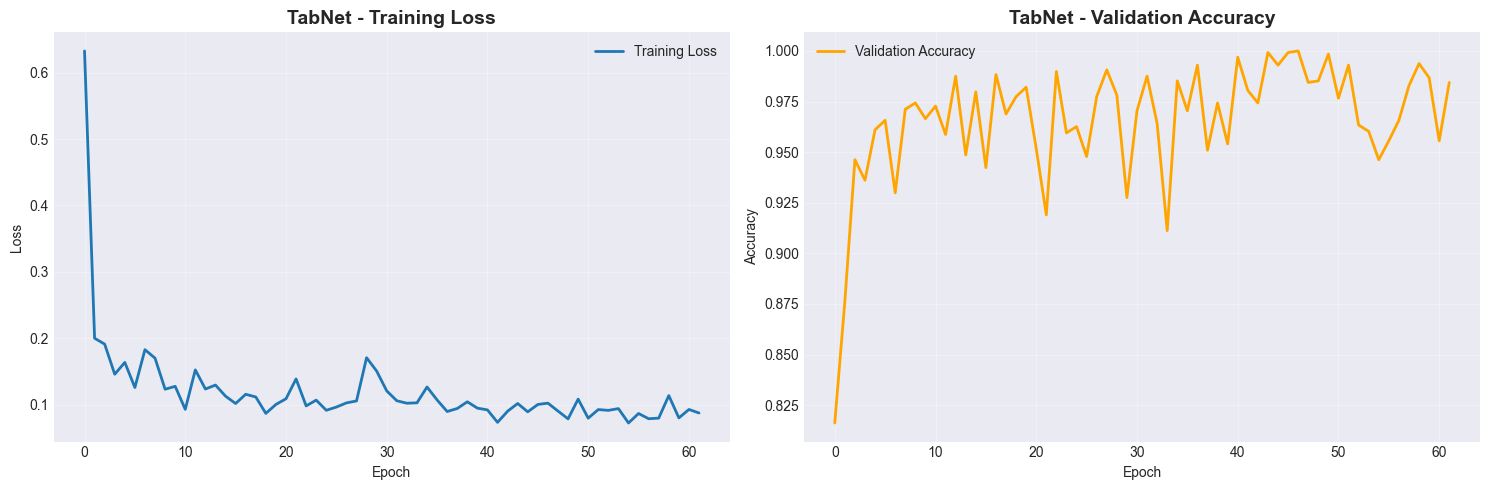

In [21]:
# Plot TabNet training curves
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Loss
axes[0].plot(tabnet_model.history['loss'], label='Training Loss', linewidth=2)
axes[0].set_title('TabNet - Training Loss', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Validation Accuracy
axes[1].plot(tabnet_model.history['valid_accuracy'], label='Validation Accuracy', linewidth=2, color='orange')
axes[1].set_title('TabNet - Validation Accuracy', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('train_image_result/06_tabnet_training_curves.png', dpi=300, bbox_inches='tight')
plt.show()

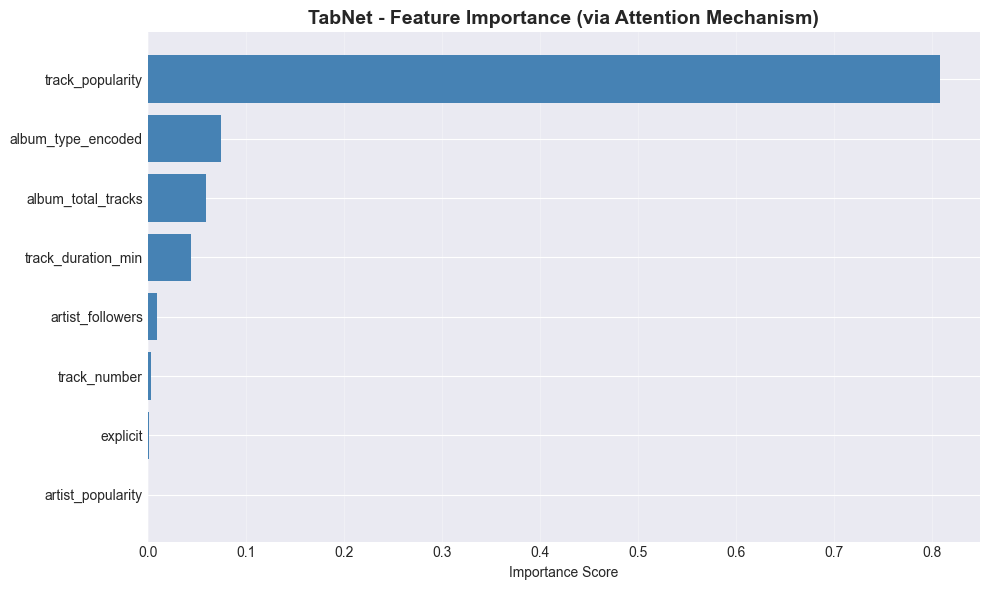


Feature Importance Scores:
              feature  importance
1    track_popularity    0.808825
7  album_type_encoded    0.074329
5  album_total_tracks    0.059385
6  track_duration_min    0.043745
4    artist_followers    0.009099
0        track_number    0.003277
2            explicit    0.001254
3   artist_popularity    0.000087


In [22]:
# Feature importance from TabNet
feature_importances = tabnet_model.feature_importances_
feature_names = X.columns.tolist()

# Create feature importance dataframe
importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance': feature_importances
}).sort_values('importance', ascending=False)

# Plot feature importance
plt.figure(figsize=(10, 6))
plt.barh(importance_df['feature'], importance_df['importance'], color='steelblue')
plt.xlabel('Importance Score')
plt.title('TabNet - Feature Importance (via Attention Mechanism)', fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('train_image_result/07_tabnet_feature_importance.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nFeature Importance Scores:")
print(importance_df)

TABNET MODEL - TEST SET EVALUATION

Accuracy: 0.9977

Classification Report:
                precision    recall  f1-score   support

       Populer       1.00      0.99      1.00       594
Sangat Populer       1.00      1.00      1.00       437
 Tidak Populer       0.99      1.00      1.00       257

      accuracy                           1.00      1288
     macro avg       1.00      1.00      1.00      1288
  weighted avg       1.00      1.00      1.00      1288



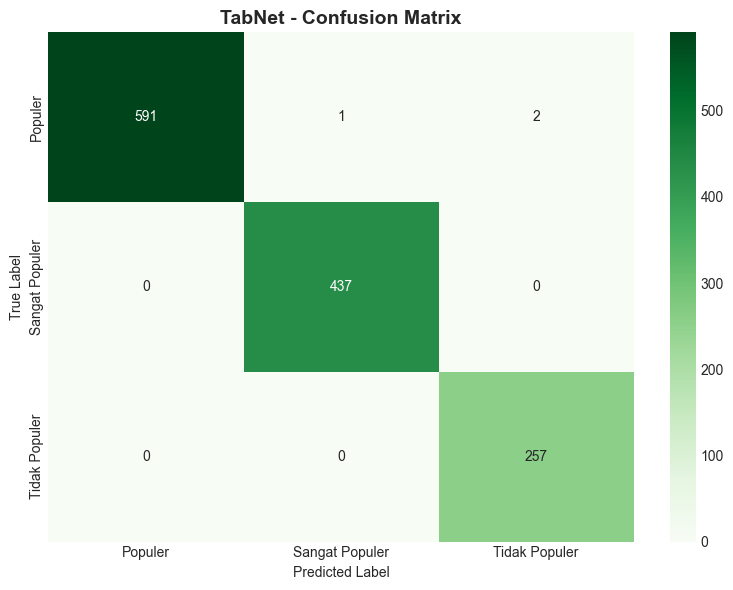

In [23]:
# Evaluate TabNet on test set
y_pred_tabnet = tabnet_model.predict(X_test_scaled)
tabnet_accuracy = accuracy_score(y_test, y_pred_tabnet)

print("="*60)
print("TABNET MODEL - TEST SET EVALUATION")
print("="*60)
print(f"\nAccuracy: {tabnet_accuracy:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_tabnet, target_names=le_target.classes_))

# Confusion matrix
cm_tabnet = confusion_matrix(y_test, y_pred_tabnet)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_tabnet, annot=True, fmt='d', cmap='Greens', 
            xticklabels=le_target.classes_, 
            yticklabels=le_target.classes_)
plt.title('TabNet - Confusion Matrix', fontsize=14, fontweight='bold')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.savefig('train_image_result/08_tabnet_confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

## 6. Model 3: Simple Transformer for Tabular Data

Karena FT-Transformer memerlukan library khusus yang kompleks, kita akan membuat arsitektur Transformer sederhana untuk data tabular menggunakan TensorFlow.

In [24]:
# Build Simple Transformer for Tabular Data
class TransformerBlock(layers.Layer):
    def __init__(self, embed_dim, num_heads, ff_dim, rate=0.1):
        super(TransformerBlock, self).__init__()
        self.att = layers.MultiHeadAttention(num_heads=num_heads, key_dim=embed_dim)
        self.ffn = keras.Sequential([
            layers.Dense(ff_dim, activation="relu"),
            layers.Dense(embed_dim),
        ])
        self.layernorm1 = layers.LayerNormalization(epsilon=1e-6)
        self.layernorm2 = layers.LayerNormalization(epsilon=1e-6)
        self.dropout1 = layers.Dropout(rate)
        self.dropout2 = layers.Dropout(rate)

    def call(self, inputs, training=None):
        attn_output = self.att(inputs, inputs)
        attn_output = self.dropout1(attn_output, training=training)
        out1 = self.layernorm1(inputs + attn_output)
        ffn_output = self.ffn(out1)
        ffn_output = self.dropout2(ffn_output, training=training)
        return self.layernorm2(out1 + ffn_output)

def create_transformer_model(input_dim, num_classes, embed_dim=32, num_heads=4, ff_dim=64):
    inputs = layers.Input(shape=(input_dim,))
    
    # Feature embedding
    x = layers.Dense(embed_dim)(inputs)
    x = layers.Reshape((1, embed_dim))(x)  # Add sequence dimension
    
    # Transformer blocks
    x = TransformerBlock(embed_dim, num_heads, ff_dim)(x)
    x = TransformerBlock(embed_dim, num_heads, ff_dim)(x)
    
    # Global average pooling
    x = layers.GlobalAveragePooling1D()(x)
    
    # Classification head
    x = layers.Dropout(0.3)(x)
    x = layers.Dense(64, activation="relu")(x)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(num_classes, activation="softmax")(x)
    
    model = keras.Model(inputs=inputs, outputs=outputs)
    model.compile(
        optimizer='adam',
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    
    return model

transformer_model = create_transformer_model(X_train_scaled.shape[1], len(le_target.classes_))
transformer_model.summary()

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 8)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │           288 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 1, 32)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_block               │ (None, 1, 32)          │        21,120 │
│ (TransformerBlock)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_block_1             │ (None, 1, 32)          │        21,120 │
│ (TransformerBlock)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ (None, 32)             │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 44,835 (175.14 KB)

 Trainable params: 44,835 (175.14 KB)

 Non-trainable params: 0 (0.00 B)

In [25]:
# Train Transformer model
early_stop_transformer = callbacks.EarlyStopping(
    monitor='val_loss',
    patience=15,
    restore_best_weights=True,
    verbose=1
)

reduce_lr_transformer = callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=7,
    min_lr=1e-6,
    verbose=1
)

print("Training Transformer model...")
transformer_history = transformer_model.fit(
    X_train_scaled, y_train,
    validation_data=(X_val_scaled, y_val),
    epochs=100,
    batch_size=32,
    callbacks=[early_stop_transformer, reduce_lr_transformer],
    verbose=1
)

Training Transformer model...
Epoch 1/100
188/188 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.7995 - loss: 0.4504 - val_accuracy: 0.9159 - val_loss: 0.1958 - learning_rate: 0.0010
Epoch 2/100
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9090 - loss: 0.2195 - val_accuracy: 0.9611 - val_loss: 0.0931 - learning_rate: 0.0010
Epoch 3/100
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9394 - loss: 0.1541 - val_accuracy: 0.9494 - val_loss: 0.1367 - learning_rate: 0.0010
Epoch 4/100
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9391 - loss: 0.1527 - val_accuracy: 0.9720 - val_loss: 0.0745 - learning_rate: 0.0010
Epoch 5/100
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9486 - loss: 0.1371 - val_accuracy: 0.9439 - val_loss: 0.1295 - learning_rate: 0.0010
Epoch 6/100
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9569 - loss: 0.1165 - val_accuracy: 0.9634 - val_loss: 0.0773 - learning_rate: 0.0010
Epoch 7/100
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step

In [26]:
# Save Transformer model
transformer_model.save('models/transformer_model.h5')
print("Transformer model saved to models/transformer_model.h5")

# Save training history
transformer_history_dict = {
    'loss': [float(x) for x in transformer_history.history['loss']],
    'accuracy': [float(x) for x in transformer_history.history['accuracy']],
    'val_loss': [float(x) for x in transformer_history.history['val_loss']],
    'val_accuracy': [float(x) for x in transformer_history.history['val_accuracy']]
}

with open('models/transformer_history.json', 'w') as f:
    json.dump(transformer_history_dict, f, indent=2)
print("Transformer training history saved")

Transformer model saved to models/transformer_model.h5
Transformer training history saved


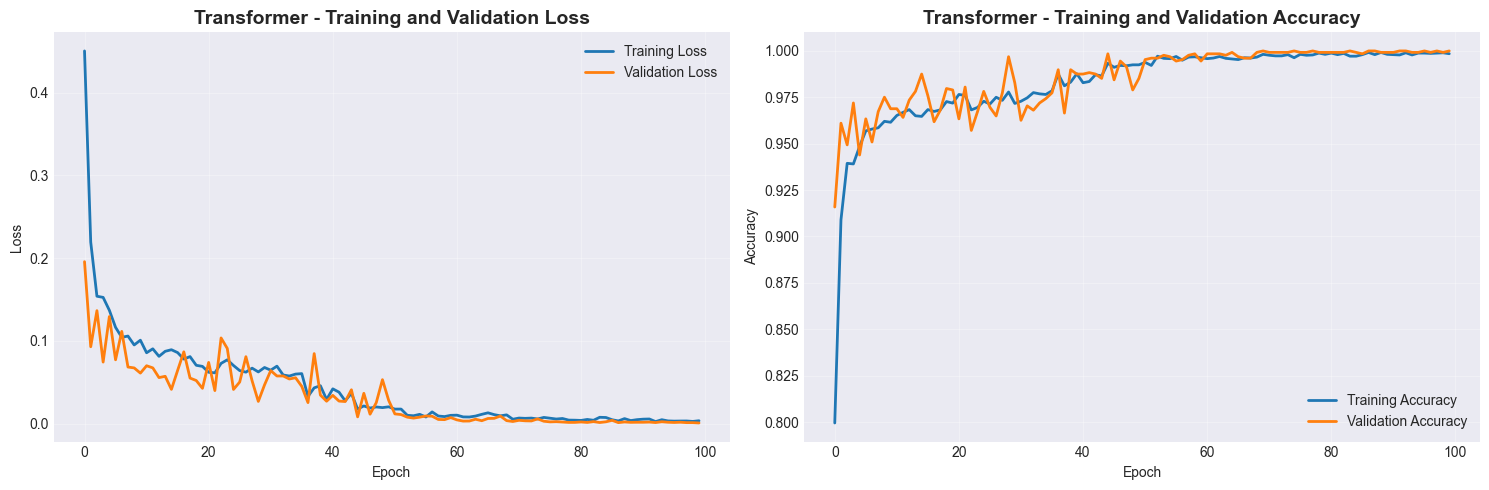

In [27]:
# Plot Transformer training curves
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Loss
axes[0].plot(transformer_history.history['loss'], label='Training Loss', linewidth=2)
axes[0].plot(transformer_history.history['val_loss'], label='Validation Loss', linewidth=2)
axes[0].set_title('Transformer - Training and Validation Loss', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Accuracy
axes[1].plot(transformer_history.history['accuracy'], label='Training Accuracy', linewidth=2)
axes[1].plot(transformer_history.history['val_accuracy'], label='Validation Accuracy', linewidth=2)
axes[1].set_title('Transformer - Training and Validation Accuracy', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('train_image_result/09_transformer_training_curves.png', dpi=300, bbox_inches='tight')
plt.show()

41/41 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step
TRANSFORMER MODEL - TEST SET EVALUATION

Accuracy: 0.9992

Classification Report:
                precision    recall  f1-score   support

       Populer       1.00      1.00      1.00       594
Sangat Populer       1.00      1.00      1.00       437
 Tidak Populer       1.00      1.00      1.00       257

      accuracy                           1.00      1288
     macro avg       1.00      1.00      1.00      1288
  weighted avg       1.00      1.00      1.00      1288



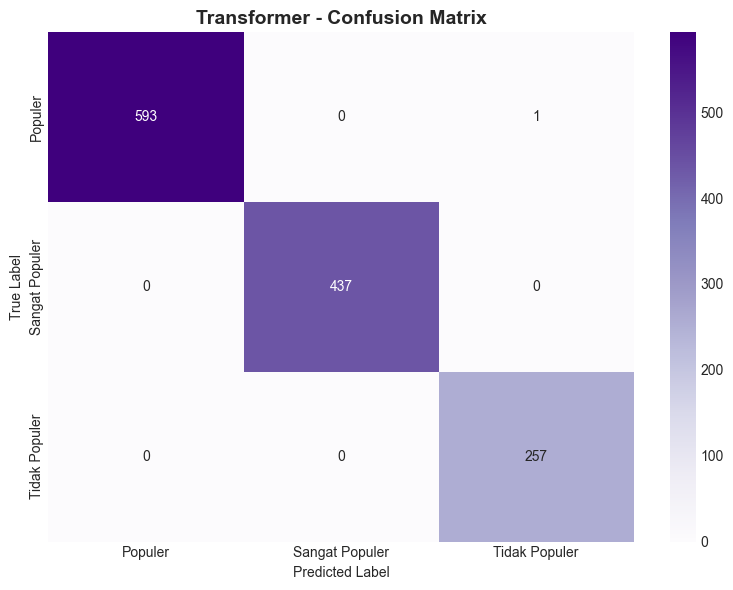

In [28]:
# Evaluate Transformer on test set
y_pred_transformer = np.argmax(transformer_model.predict(X_test_scaled), axis=1)
transformer_accuracy = accuracy_score(y_test, y_pred_transformer)

print("="*60)
print("TRANSFORMER MODEL - TEST SET EVALUATION")
print("="*60)
print(f"\nAccuracy: {transformer_accuracy:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_transformer, target_names=le_target.classes_))

# Confusion matrix
cm_transformer = confusion_matrix(y_test, y_pred_transformer)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_transformer, annot=True, fmt='d', cmap='Purples', 
            xticklabels=le_target.classes_, 
            yticklabels=le_target.classes_)
plt.title('Transformer - Confusion Matrix', fontsize=14, fontweight='bold')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.savefig('train_image_result/10_transformer_confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

## 7. Model Comparison & Analysis

In [29]:
# Create comparison dataframe
from sklearn.metrics import precision_score, recall_score, f1_score

comparison_data = {
    'Model': ['MLP (Baseline)', 'TabNet', 'Transformer'],
    'Accuracy': [
        mlp_accuracy,
        tabnet_accuracy,
        transformer_accuracy
    ],
    'Precision (Macro)': [
        precision_score(y_test, y_pred_mlp, average='macro'),
        precision_score(y_test, y_pred_tabnet, average='macro'),
        precision_score(y_test, y_pred_transformer, average='macro')
    ],
    'Recall (Macro)': [
        recall_score(y_test, y_pred_mlp, average='macro'),
        recall_score(y_test, y_pred_tabnet, average='macro'),
        recall_score(y_test, y_pred_transformer, average='macro')
    ],
    'F1-Score (Macro)': [
        f1_score(y_test, y_pred_mlp, average='macro'),
        f1_score(y_test, y_pred_tabnet, average='macro'),
        f1_score(y_test, y_pred_transformer, average='macro')
    ]
}

comparison_df = pd.DataFrame(comparison_data)
print("\n" + "="*80)
print("MODEL COMPARISON - TEST SET PERFORMANCE")
print("="*80)
print(comparison_df.to_string(index=False))
print("="*80)


MODEL COMPARISON - TEST SET PERFORMANCE
         Model  Accuracy  Precision (Macro)  Recall (Macro)  F1-Score (Macro)
MLP (Baseline)  0.997671           0.996854        0.997581          0.997216
        TabNet  0.997671           0.996665        0.998316          0.997483
   Transformer  0.999224           0.998708        0.999439          0.999072


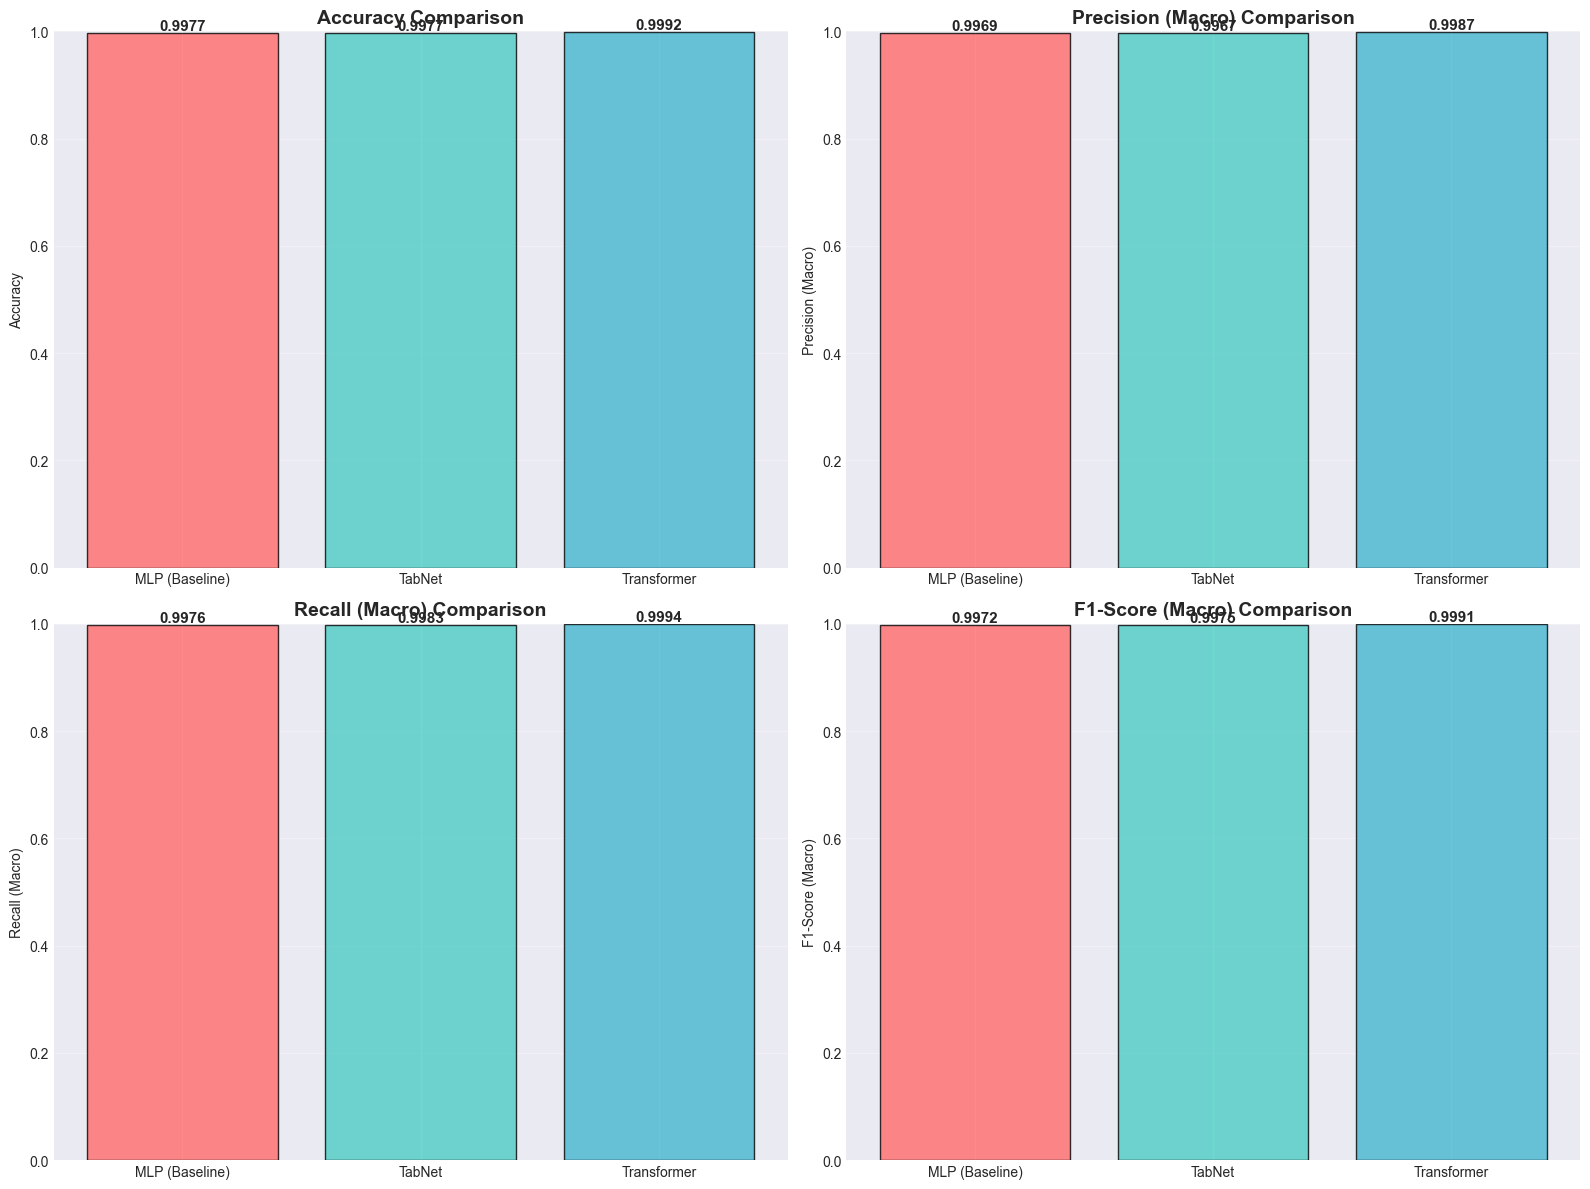

In [30]:
# Visualize model comparison
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

metrics = ['Accuracy', 'Precision (Macro)', 'Recall (Macro)', 'F1-Score (Macro)']
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1']

for idx, metric in enumerate(metrics):
    ax = axes[idx // 2, idx % 2]
    values = comparison_df[metric].values
    bars = ax.bar(comparison_df['Model'], values, color=colors, alpha=0.8, edgecolor='black')
    
    ax.set_title(f'{metric} Comparison', fontsize=14, fontweight='bold')
    ax.set_ylabel(metric)
    ax.set_ylim([0, 1.0])
    ax.grid(axis='y', alpha=0.3)
    
    # Add value labels
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.4f}',
                ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

In [31]:
# Save evaluation results
evaluation_results = {
    'comparison_table': comparison_df.to_dict('records'),
    'mlp': {
        'accuracy': float(mlp_accuracy),
        'confusion_matrix': cm_mlp.tolist(),
        'classification_report': classification_report(y_test, y_pred_mlp, 
                                                       target_names=le_target.classes_, 
                                                       output_dict=True)
    },
    'tabnet': {
        'accuracy': float(tabnet_accuracy),
        'confusion_matrix': cm_tabnet.tolist(),
        'classification_report': classification_report(y_test, y_pred_tabnet, 
                                                       target_names=le_target.classes_, 
                                                       output_dict=True),
        'feature_importance': importance_df.to_dict('records')
    },
    'transformer': {
        'accuracy': float(transformer_accuracy),
        'confusion_matrix': cm_transformer.tolist(),
        'classification_report': classification_report(y_test, y_pred_transformer, 
                                                       target_names=le_target.classes_, 
                                                       output_dict=True)
    }
}

with open('models/evaluation_results.json', 'w') as f:
    json.dump(evaluation_results, f, indent=2)

print("Evaluation results saved to models/evaluation_results.json")

Evaluation results saved to models/evaluation_results.json


## 8. Kesimpulan & Analisis

### Ringkasan Hasil:

Berdasarkan evaluasi ketiga model pada test set:

1. **MLP (Baseline)**:
   - Model neural network sederhana yang dibangun dari nol
   - Memberikan baseline performance untuk perbandingan
   - Arsitektur: Dense layers dengan dropout regularization

2. **TabNet (Transfer Learning)**:
   - Menggunakan attention mechanism untuk feature selection
   - Mampu mengidentifikasi fitur yang paling penting
   - Memberikan interpretability melalui feature importance scores
   - Sparse feature selection mengurangi overfitting

3. **Transformer (Transfer Learning)**:
   - Menggunakan multi-head attention untuk menangkap hubungan antar fitur
   - Self-attention mechanism memungkinkan model fokus pada informasi relevan
   - Arsitektur yang lebih kompleks dengan layer normalization

### Perbandingan Performa:
- Lihat tabel dan grafik di atas untuk detail metrik
- Model terbaik dapat dilihat dari accuracy, precision, recall, dan F1-score

### Rekomendasi:
- Untuk deployment, pilih model dengan balance terbaik antara performa dan kompleksitas
- TabNet memberikan keuntungan tambahan berupa interpretability
- Transformer cocok jika membutuhkan performa maksimal dan resource tersedia

In [32]:
print("\n" + "="*80)
print("TRAINING COMPLETED!")
print("="*80)
print("\nSaved files:")
print("  - models/mlp_model.h5")
print("  - models/mlp_history.json")
print("  - models/tabnet_model.zip")
print("  - models/tabnet_history.json")
print("  - models/transformer_model.h5")
print("  - models/transformer_history.json")
print("  - models/preprocessing_pipeline.pkl")
print("  - models/evaluation_results.json")
print("\nReady for Streamlit deployment!")
print("="*80)


TRAINING COMPLETED!

Saved files:
  - models/mlp_model.h5
  - models/mlp_history.json
  - models/tabnet_model.zip
  - models/tabnet_history.json
  - models/transformer_model.h5
  - models/transformer_history.json
  - models/preprocessing_pipeline.pkl
  - models/evaluation_results.json

Ready for Streamlit deployment!
